<a href="https://colab.research.google.com/github/wesleymelodev/golden-ratio-deep-learning/blob/main/golden-ratio-deep-learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import _LRScheduler
import torch.nn.functional as F
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
import datetime
from PIL import Image
import glob
import math
import torch.nn as nn

drive.mount('/content/drive')
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
plt.savefig(f'grafico_phi_{timestamp}.png', dpi=300, bbox_inches='tight')

# Transformação: converte imagem em tensor e normaliza
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Carregar MNIST
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Criar DataLoaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)


# Inicialização
def apply_golden_init(layer):
    phi = (1 + math.sqrt(5)) / 2
    if isinstance(layer, (nn.Linear, nn.Conv2d)):
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(layer.weight)
        std = phi / math.sqrt(fan_in)
        nn.init.normal_(layer.weight, mean=0.0, std=std)
        if layer.bias is not None:
            nn.init.constant_(layer.bias, 0.0)

# Exemplo: aplicar em um modelo simples
class GoldenMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 10)
        self.apply(apply_golden_init)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


# compressão topologica
def generate_phi_architecture(input_dim, depth):
    phi_inv = 0.61803398875
    layers = []
    current_dim = input_dim
    for i in range(depth):
        next_dim = math.ceil(current_dim * phi_inv)
        layers.append(next_dim)
        current_dim = next_dim
    return layers

# Exemplo: entrada 1024, profundidade 4
print(generate_phi_architecture(1024, 4))  # [633, 392, 243, 151]


# Dropout Áureo (~38,2%)
phi = (1 + math.sqrt(5)) / 2
p_drop = 1 - (1/phi)  # ≈ 0.382

class GoldenDropoutModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.dropout = nn.Dropout(p=p_drop)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


# Dropout Áureo (~38,2%)
phi = (1 + math.sqrt(5)) / 2
p_drop = 1 - (1/phi)  # ≈ 0.382

class GoldenDropoutModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.dropout = nn.Dropout(p=p_drop)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)



# Scheduler de Aprendizado Áureo
class GoldenStepLR(_LRScheduler):
    def __init__(self, optimizer, step_size, last_epoch=-1):
        self.phi_inv = 0.61803398875
        self.step_size = step_size
        super(GoldenStepLR, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        if (self.last_epoch == 0) or (self.last_epoch % self.step_size != 0):
            return [group['lr'] for group in self.optimizer.param_groups]
        return [group['lr'] * self.phi_inv for group in self.optimizer.param_groups]

# Exemplo de uso
model = GoldenMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
scheduler = GoldenStepLR(optimizer, step_size=5)


# Atenção Escalonada por ϕ
def golden_scaled_dot_product_attention(q, k, v, mask=None):
    phi = 1.61803398875
    d_k = q.size(-1)
    attn_logits = torch.matmul(q, k.transpose(-2, -1)) / (phi * math.sqrt(d_k))
    if mask is not None:
        attn_logits = attn_logits.masked_fill(mask == 0, -1e9)
    attention_weights = F.softmax(attn_logits, dim=-1)
    values = torch.matmul(attention_weights, v)
    return values, attention_weights


# Treinamento
train_losses = []
test_accuracies = []
criterion = nn.CrossEntropyLoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(10):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.view(images.size(0), -1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    scheduler.step()

    # Avaliação por época
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            images = images.view(images.size(0), -1)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    test_accuracies.append(epoch_acc)

    print(f"Época {epoch+1}: perda média = {epoch_loss:.4f}, acurácia = {epoch_acc:.2f}%")

# Avaliar desempenho
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        images = images.view(images.size(0), -1)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Acurácia: {100 * correct / total:.2f}%")

# --- Gráficos finais ---
plt.figure(figsize=(12,5))

# Gráfico de perda com linha suave
plt.subplot(1,2,1)
sns.lineplot(x=range(len(train_losses)), y=train_losses, marker='o', color='gold')
plt.title('Evolução da Perda (Loss)')
plt.xlabel('Época')
plt.ylabel('Perda média')

# Anotação automática: menor perda
min_loss = np.min(train_losses)
min_epoch = np.argmin(train_losses)
plt.annotate(f'Menor perda: {min_loss:.4f}',
             xy=(min_epoch, min_loss),
             xytext=(min_epoch, min_loss + 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='black')

# Gráfico de acurácia com linha suave
plt.subplot(1,2,2)
sns.lineplot(x=range(len(test_accuracies)), y=test_accuracies, marker='o', color='darkorange')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')

# Anotação automática: maior acurácia
max_acc = np.max(test_accuracies)
max_epoch = np.argmax(test_accuracies)
plt.annotate(f'Maior acurácia: {max_acc:.2f}%',
             xy=(max_epoch, max_acc),
             xytext=(max_epoch, max_acc - 5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='black')

plt.tight_layout()

# Salvar automaticamente no Drive
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
save_path = f"/content/drive/MyDrive/grafico_phi_epoca_final_{timestamp}.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.close()  # fecha o gráfico para liberar memória

print(f"Gráfico final salvo em: {save_path}")

# --- Criar GIF com todos os gráficos por época ---
path = "/content/drive/MyDrive/"

# Buscar todos os arquivos que começam com 'grafico_phi_epoca'
frames = sorted(glob.glob(f"{path}grafico_phi_epoca_*.png"))
print(f"Total de gráficos encontrados: {len(frames)}")

if frames:
    images = [Image.open(frame) for frame in frames]
    gif_path = f"{path}evolucao_phi_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}.gif"
    images[0].save(
        gif_path,
        save_all=True,
        append_images=images[1:],
        duration=800,  # tempo entre frames (ms)
        loop=0         # 0 = loop infinito
    )
    print(f"GIF criado e salvo em: {gif_path}")
else:
    print("Nenhum gráfico encontrado para gerar GIF.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[633, 392, 243, 151]
Época 1: perda média = 0.4758, acurácia = 92.63%
Época 2: perda média = 0.2380, acurácia = 93.46%
Época 3: perda média = 0.2403, acurácia = 91.12%
Época 4: perda média = 0.2290, acurácia = 93.71%
Época 5: perda média = 0.2161, acurácia = 92.15%
Época 6: perda média = 0.1606, acurácia = 95.83%
Época 7: perda média = 0.1489, acurácia = 95.14%
Época 8: perda média = 0.1524, acurácia = 94.86%
Época 9: perda média = 0.1474, acurácia = 95.43%
Época 10: perda média = 0.1433, acurácia = 95.63%
Acurácia: 95.63%
Gráfico final salvo em: /content/drive/MyDrive/grafico_phi_epoca_final_2026-05-14_00-57-40.png
Total de gráficos encontrados: 2
GIF criado e salvo em: /content/drive/MyDrive/evolucao_phi_2026-05-14_00-57-40.gif


<Figure size 640x480 with 0 Axes>

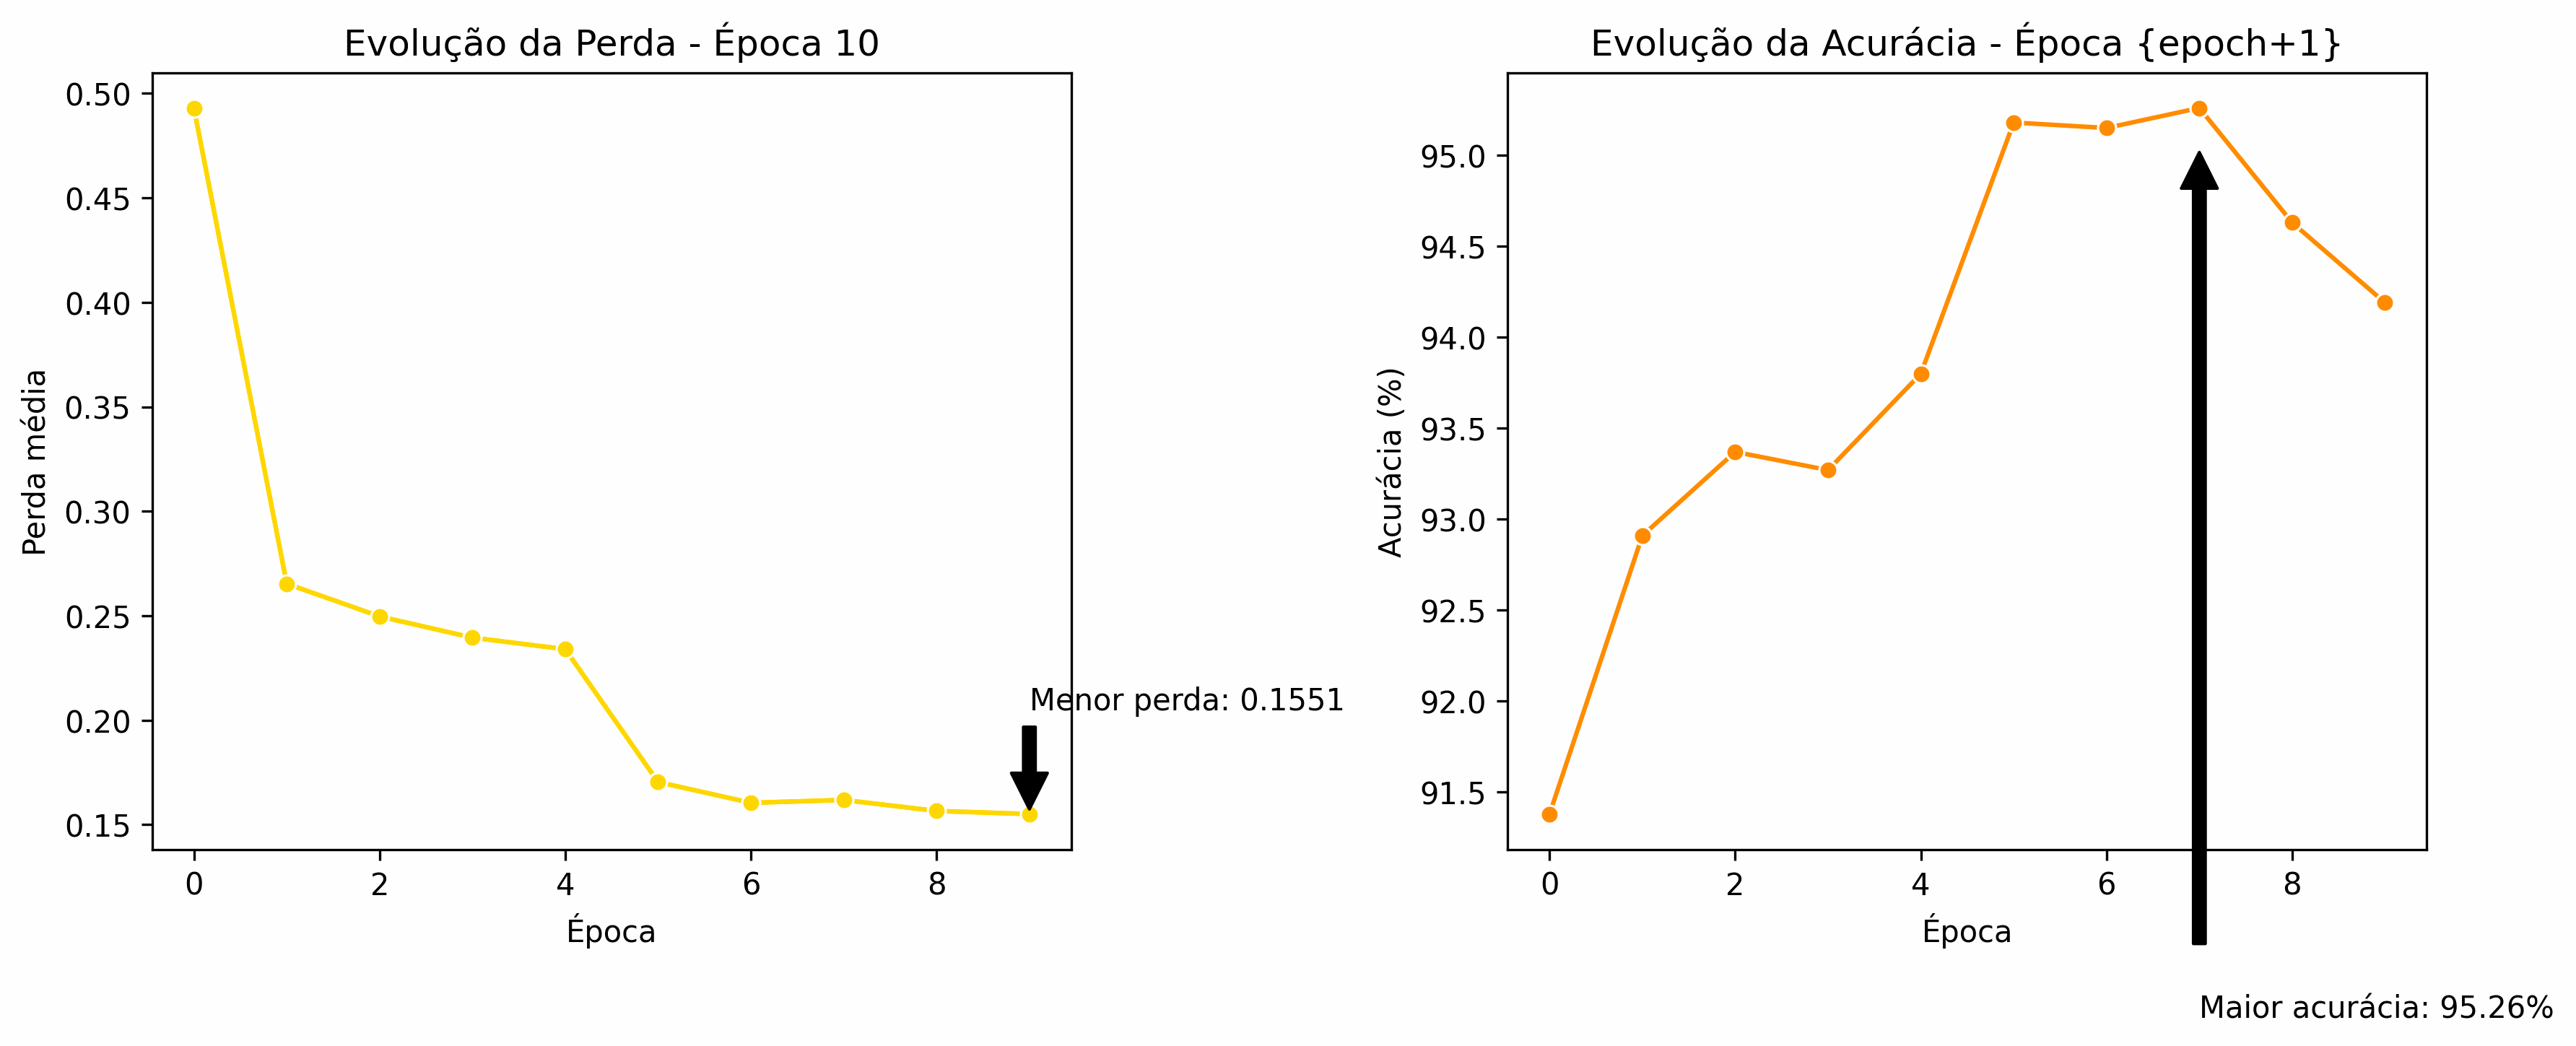

[Xavier] Época 1: perda média = 0.9673, acurácia = 88.72%
[Xavier] Época 2: perda média = 0.8002, acurácia = 89.72%
[Xavier] Época 3: perda média = 0.8154, acurácia = 89.56%
[Xavier] Época 4: perda média = 0.7878, acurácia = 90.23%
[Xavier] Época 5: perda média = 0.7737, acurácia = 90.67%
[Xavier] Época 6: perda média = 0.6299, acurácia = 91.71%
[Xavier] Época 7: perda média = 0.6168, acurácia = 91.91%
[Xavier] Época 8: perda média = 0.6126, acurácia = 92.17%
[Xavier] Época 9: perda média = 0.6018, acurácia = 92.53%
[Xavier] Época 10: perda média = 0.6106, acurácia = 92.14%


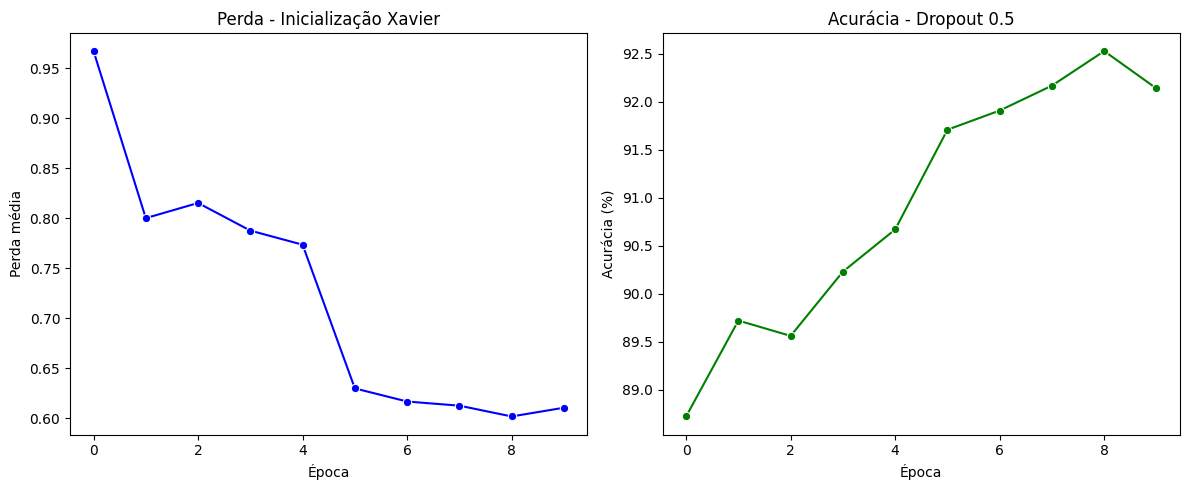

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Dataset MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

# Modelo com inicialização Xavier e dropout padrão
class StandardMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.dropout = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(256, 10)
        self.apply(self._init_weights)

    def _init_weights(self, layer):
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight)
            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0.0)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

# Configuração de treino
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_std = StandardMLP().to(device)
optimizer_std = torch.optim.Adam(model_std.parameters(), lr=0.01)
scheduler_std = StepLR(optimizer_std, step_size=5, gamma=0.5)
criterion = nn.CrossEntropyLoss()

train_losses_std = []
test_accuracies_std = []

# Loop de treino
for epoch in range(10):
    model_std.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_std.zero_grad()
        outputs = model_std(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_std.step()
        running_loss += loss.item()
    scheduler_std.step()

    # Avaliação
    model_std.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_std(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    train_losses_std.append(epoch_loss)
    test_accuracies_std.append(epoch_acc)

    print(f"[Xavier] Época {epoch+1}: perda média = {epoch_loss:.4f}, acurácia = {epoch_acc:.2f}%")

# Gráficos comparativos
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.lineplot(x=range(len(train_losses_std)), y=train_losses_std, marker='o', color='blue')
plt.title('Perda - Inicialização Xavier')
plt.xlabel('Época')
plt.ylabel('Perda média')

plt.subplot(1,2,2)
sns.lineplot(x=range(len(test_accuracies_std)), y=test_accuracies_std, marker='o', color='green')
plt.title('Acurácia - Dropout 0.5')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')

plt.tight_layout()
plt.show()


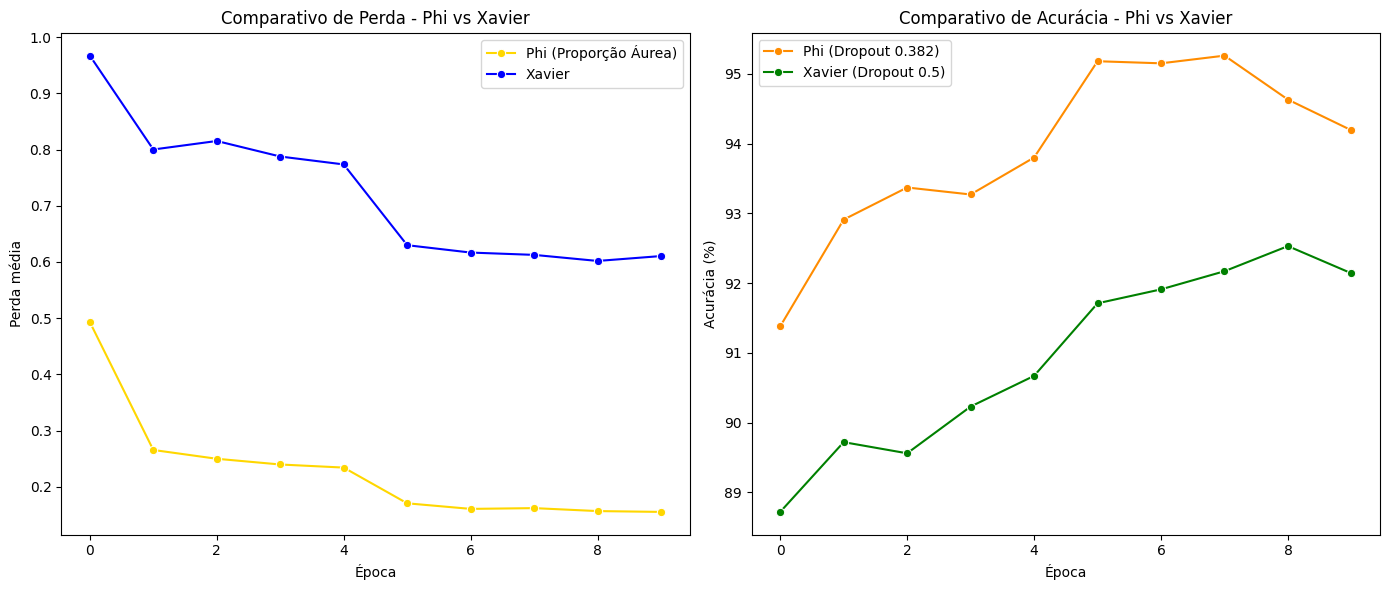

Gráfico comparativo salvo em: /content/drive/MyDrive/comparativo_phi_vs_xavier.png


<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

# Comparação da perda
plt.subplot(1,2,1)
sns.lineplot(x=range(len(train_losses)), y=train_losses, marker='o', color='gold', label='Phi (Proporção Áurea)')
sns.lineplot(x=range(len(train_losses_std)), y=train_losses_std, marker='o', color='blue', label='Xavier')
plt.title('Comparativo de Perda - Phi vs Xavier')
plt.xlabel('Época')
plt.ylabel('Perda média')
plt.legend()

# Comparação da acurácia
plt.subplot(1,2,2)
sns.lineplot(x=range(len(test_accuracies)), y=test_accuracies, marker='o', color='darkorange', label='Phi (Dropout 0.382)')
sns.lineplot(x=range(len(test_accuracies_std)), y=test_accuracies_std, marker='o', color='green', label='Xavier (Dropout 0.5)')
plt.title('Comparativo de Acurácia - Phi vs Xavier')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()

plt.tight_layout()
plt.show()

save_path = '/content/drive/MyDrive/comparativo_phi_vs_xavier.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Gráfico comparativo salvo em: {save_path}")


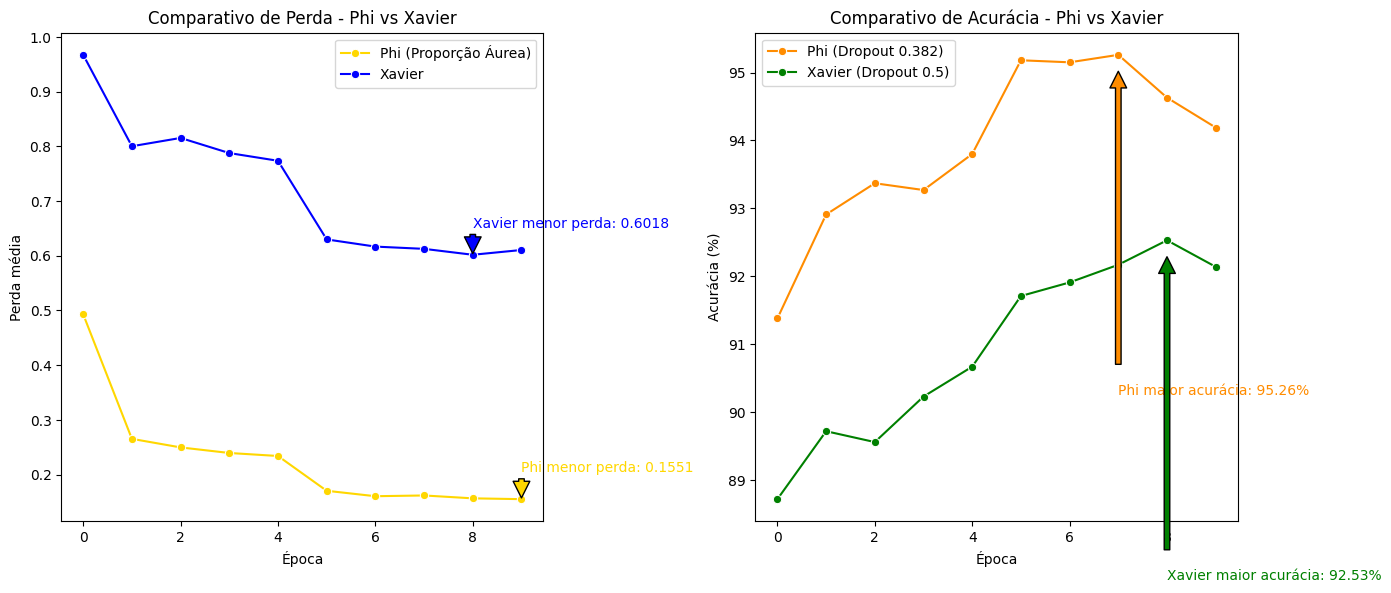

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

# Comparação da perda
plt.subplot(1,2,1)
sns.lineplot(x=range(len(train_losses)), y=train_losses, marker='o', color='gold', label='Phi (Proporção Áurea)')
sns.lineplot(x=range(len(train_losses_std)), y=train_losses_std, marker='o', color='blue', label='Xavier')
plt.title('Comparativo de Perda - Phi vs Xavier')
plt.xlabel('Época')
plt.ylabel('Perda média')
plt.legend()

# 🔹 Anotações automáticas para perda
min_phi_loss = np.min(train_losses)
min_phi_epoch = np.argmin(train_losses)
plt.annotate(f'Phi menor perda: {min_phi_loss:.4f}',
             xy=(min_phi_epoch, min_phi_loss),
             xytext=(min_phi_epoch, min_phi_loss + 0.05),
             arrowprops=dict(facecolor='gold', shrink=0.05),
             fontsize=10, color='gold')

min_xavier_loss = np.min(train_losses_std)
min_xavier_epoch = np.argmin(train_losses_std)
plt.annotate(f'Xavier menor perda: {min_xavier_loss:.4f}',
             xy=(min_xavier_epoch, min_xavier_loss),
             xytext=(min_xavier_epoch, min_xavier_loss + 0.05),
             arrowprops=dict(facecolor='blue', shrink=0.05),
             fontsize=10, color='blue')

# Comparação da acurácia
plt.subplot(1,2,2)
sns.lineplot(x=range(len(test_accuracies)), y=test_accuracies, marker='o', color='darkorange', label='Phi (Dropout 0.382)')
sns.lineplot(x=range(len(test_accuracies_std)), y=test_accuracies_std, marker='o', color='green', label='Xavier (Dropout 0.5)')
plt.title('Comparativo de Acurácia - Phi vs Xavier')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()

# 🔹 Anotações automáticas para acurácia
max_phi_acc = np.max(test_accuracies)
max_phi_epoch = np.argmax(test_accuracies)
plt.annotate(f'Phi maior acurácia: {max_phi_acc:.2f}%',
             xy=(max_phi_epoch, max_phi_acc),
             xytext=(max_phi_epoch, max_phi_acc - 5),
             arrowprops=dict(facecolor='darkorange', shrink=0.05),
             fontsize=10, color='darkorange')

max_xavier_acc = np.max(test_accuracies_std)
max_xavier_epoch = np.argmax(test_accuracies_std)
plt.annotate(f'Xavier maior acurácia: {max_xavier_acc:.2f}%',
             xy=(max_xavier_epoch, max_xavier_acc),
             xytext=(max_xavier_epoch, max_xavier_acc - 5),
             arrowprops=dict(facecolor='green', shrink=0.05),
             fontsize=10, color='green')

plt.tight_layout()
plt.show()
